# Sección 1 — Librerías y configuración global
Importar librerías necesarias y definir parámetros por defecto del proyecto.


In [ ]:
pip install scipy

In [ ]:
# ==============================
# IMPORTACIÓN DE LIBRERÍAS
# ==============================

import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import serial  # requiere pyserial instalado en el entorno local
from scipy.signal import windows, hilbert, medfilt
from scipy.fft import fft, fftfreq
from scipy.stats import linregress

In [ ]:
# ==============================
# PARÁMETROS GENERALES DEL EXPERIMENTO
# ==============================

PUERTO = 'COM10'        # cambia si es necesario
BAUDRATE = 115200
N_MUESTRAS = 40000      # muestras por ensayo (ajusta duración)
CARPETA_SALIDA = "salida2"
DEFAULT_MEDFILT_KERNEL = 101  # para suavizado de envolvente (impar)
THRESHOLD_FRAC = 0.10   # fracción del máximo para seleccionar región de ajuste de la envolvente

os.makedirs(CARPETA_SALIDA, exist_ok=True)

## Sección 2 — Adquisición por Serial (ESP32)
**Descripción.** Abrir el puerto serial, leer `N_MUESTRAS` líneas, almacenar lecturas crudas en `voltajes` y su índice en `tiempo_idx`.  
**Notas prácticas.** NO se envía ningún comando al micro (no hay `ser.write(b'a')`, eliminado por ser superfluo). Se mide el tiempo de adquisición para estimar `fs` real (`fs_est`).


In [ ]:
# Sección 2 - Adquisición por Serial (ESP32)
def acquire_trial(trial_label=None, n_samples=N_MUESTRAS, puerto=PUERTO, baudrate=BAUDRATE, wait_before=1.0):
    try:
        ser = serial.Serial(puerto, baudrate, timeout=2)
        print(f"Conectado a {puerto}. Esperando {wait_before}s...")
        time.sleep(wait_before) # Estabilización
        ser.reset_input_buffer()

        voltajes_local = []
        tiempo_idx_local = []

        t_start = time.time()
        count = 0

        print(f"Iniciando captura de {n_samples} muestras...")
        while count < n_samples:
            linea = ser.readline().decode('utf-8', errors='ignore').strip()
            count += 1
            tiempo_idx_local.append(count)

            if not linea:
                voltajes_local.append(np.nan)
                continue
            try:
                voltajes_local.append(float(linea))
            except ValueError:
                voltajes_local.append(np.nan)

        t_end = time.time()
        ser.close()

        duracion = t_end - t_start
        fs_est_local = count / duracion if duracion > 0 else 0
        t_sec_local = (np.array(tiempo_idx_local, dtype=float) - 1) / fs_est_local

        print(f"Captura completa. fs estimada: {fs_est_local:.2f} Hz")

        # Devolvemos todo lo necesario para las siguientes secciones
        return t_sec_local, np.array(voltajes_local), fs_est_local, tiempo_idx_local

    except Exception as e:
        if 'ser' in locals() and ser.is_open:
            ser.close()
        print(f"ERROR en la conexión: {e}")
        return None, None, None, None

In [ ]:
# === ESTO CONECTA LA FUNCIÓN CON EL RESTO DEL CÓDIGO ===
# Ejecutamos la función y guardamos el resultado en variables globales
t_sec, voltajes, fs_est, tiempo_idx = acquire_trial(trial_label="ensayo_2")

if voltajes is None:
    print("Error: No se obtuvieron datos. Revisa la conexión del ESP32.")
else:
    print("Variables 'voltajes' y 'tiempo_idx' listas para el análisis.")

Conectado a COM10. Esperando 1.0s...
Iniciando captura de 40000 muestras...
Captura completa. fs estimada: 999.88 Hz
Variables 'voltajes' y 'tiempo_idx' listas para el análisis.


In [ ]:
# ---------------------------
# CALIBRACIÓN ADC (opcional)
# ---------------------------
# Si vas a calibrar, mide con un multímetro una tensión DC conocida V_cal (ej: 0.500 V)
# y toma el valor promedio de `analogRead` para esa entrada (ej: adc_cal_read).
# Rellena V_cal y adc_cal_read con tus medidas y el script calculará V_scale y V_offset.
# Si no calibras, deja V_scale = V_REF/4095 y V_offset = 0.

V_REF = 3.3  # valor nominal (sustituye si conoces otro)
USE_ADC_CALIB = False  # cambia a True si mides V_cal y adc_cal_read
V_scale = V_REF / 4095.0
V_offset = 0.0

if USE_ADC_CALIB:
    # ejemplo: si mediste con multímetro 0.500 V y el ADC devolvió 620 promedio
    V_cal = 0.500
    adc_cal_read = 620.0
    V_scale = V_cal / adc_cal_read
    V_offset = 0.0  # si detectas offset, puedes calcularlo también
    print(f"[CALIB] V_scale={V_scale:.6e} V/count")

print(f"Usando V_scale = {V_scale:.6e} V/count")

Usando V_scale = 8.058608e-04 V/count


## Sección 3 — Guardado de datos crudos (trazabilidad)
Se guarda inmediatamente un CSV con índices y lecturas brutas para auditoría y reproducibilidad. Mantener el raw permite rehacer el análisis si es necesario.


In [ ]:
# Sección 3 - Guardar datos crudos
if voltajes is not None:
    ts = time.strftime("%Y%m%d_%H%M%S")
    raw_path = os.path.join(CARPETA_SALIDA, f"medicion_raw_{ts}.csv")

    # Aseguramos que tiempo_idx y voltajes tengan la misma forma
    data_raw = np.column_stack((tiempo_idx, voltajes))

    np.savetxt(raw_path, data_raw, delimiter=",", header="index,adc", comments="")
    print(f"Datos crudos guardados con éxito en: {raw_path}")

Datos crudos guardados con éxito en: salida2\medicion_raw_20260204_151040.csv


## Sección 4 — Preprocesado mínimo (sin suavizado)
Interpolación lineal para rellenar huecos (NaN) y eliminación de la componente DC. **No** se aplica ningún filtro sobre la señal temporal; la integridad de la señal se preserva.

In [ ]:
# Sección 4 - Preprocesado mínimo
if voltajes is not None:
    # 1. Limpieza de NaNs (si hubo errores en la lectura serial)
    mask_valid = ~np.isnan(voltajes)
    if np.count_nonzero(mask_valid) < 100:
        raise RuntimeError("Demasiados datos perdidos (NaN). Revisa el cable USB.")

    # 2. Interpolación para tener una señal continua
    voltajes_interp = np.interp(t_sec, t_sec[mask_valid], voltajes[mask_valid])

    # 3. ELIMINACIÓN DE DC (Crucial para ver la oscilación)
    # Esto centra la señal en 0 en lugar de en ~2000 (o lo que sea tu offset)
    voltajes_proc = voltajes_interp - np.mean(voltajes_interp)

    print("Preprocesado completado: Señal centrada y huecos interpolados.")

Preprocesado completado: Señal centrada y huecos interpolados.


In [ ]:
# ==========================================
# SECCIÓN 4 - Preprocesado y CÁLCULO DE B (mejorado)
# ==========================================
if voltajes is not None:
    mask_valid = ~np.isnan(voltajes)
    if np.count_nonzero(mask_valid) < 100:
        raise RuntimeError("Demasiados datos perdidos (NaN). Revisa el cable USB.")
    voltajes_interp = np.interp(t_sec, t_sec[mask_valid], voltajes[mask_valid])

    # 1) Conversión a VOLTIOS (usar V_scale calculado arriba o V_REF/4095)
    voltajes_v_counts = voltajes_interp - np.mean(voltajes_interp)  # centrar counts
    voltajes_v = voltajes_v_counts * V_scale + V_offset

    # 2) AISLAR UN SOLO LÓBULO del pulso cercano al pico (evita cancelación bipolar)
    idx_max = np.argmax(np.abs(voltajes_v))
    signs = np.sign(voltajes_v)
    zero_cross = np.where(np.diff(signs) != 0)[0]

    left_candidates = zero_cross[zero_cross < idx_max]
    right_candidates = zero_cross[zero_cross > idx_max]
    inicio = int(left_candidates[-1]+1) if left_candidates.size else 0
    fin   = int(right_candidates[0])    if right_candidates.size else len(voltajes_v)-1

    # fallback: ventana simétrica si no hay cruces válidos
    if fin <= inicio:
        dt = 1.0/fs_est
        half_n = int(0.01 / dt)  # 10 ms por lado, ajustar si quieres
        inicio = max(0, idx_max - half_n)
        fin = min(len(voltajes_v)-1, idx_max + half_n)

    t_pulso = t_sec[inicio:fin+1]
    v_pulso = voltajes_v[inicio:fin+1]

    # parámetros de la bobina (ajusta si conoces mejor)
    N_VUELTAS = 3400
    RADIO_BOBINA = 0.0415
    AREA = np.pi * (RADIO_BOBINA**2)

    # 3) Integral del EMF -> flujo -> B_est
    from scipy.integrate import trapezoid
    integral_emf = np.trapezoid(v_pulso, t_pulso)  # V·s (puede ser + o -)
    B_est = np.abs(integral_emf) / (N_VUELTAS * AREA)

    # 4) Incertidumbre aproximada de la integral por ruido
    # sigma_integral ≈ sigma_V * sqrt(n) * dt  (ruido independiente por muestra)
    sigma_V = np.std(voltajes_v[:100]) if len(voltajes_v) >= 100 else np.std(voltajes_v)
    n = len(v_pulso)
    dt = np.mean(np.diff(t_pulso)) if len(t_pulso)>1 else 1.0/fs_est
    sigma_integral = sigma_V * np.sqrt(n) * dt
    delta_B = (sigma_integral / max(abs(integral_emf), 1e-12)) * B_est  # propagate

    print("--- RESULTADO B (PULSO AISLADO - método mejorado) ---")
    print(f"Integral(emf) = {integral_emf:.3e} V·s  (n={n}, dt={dt:.4e}s)")
    print(f"B = {B_est:.6e} ± {delta_B:.6e} T")
    if B_est != 0:
        print(f"Incertidumbre relativa: {100.0 * (delta_B / B_est):.2f}%")
    else:
        print("B estimado nulo (integral ~ 0). Revisa la ventana de integración.")

--- RESULTADO B (PULSO AISLADO - método mejorado) ---
Integral(emf) = 1.304e-02 V·s  (n=129, dt=1.0001e-03s)
B = 7.086074e-04 ± 9.902184e-08 T
Incertidumbre relativa: 0.01%


## Sección 5 — Visualización cruda (inspección)
Graficar puntos crudos y la señal interpolada (sin suavizar) para inspección. Esto es el control de calidad: si aquí la señal no muestra oscilaciones amortiguadas, no se procede al análisis físico.

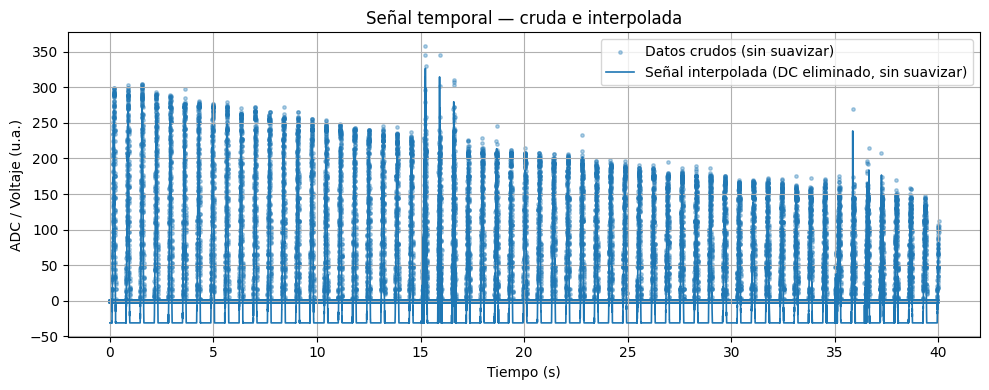

In [ ]:
# ==============================
# Sección 5 — Visualización temporal
# ==============================
plt.figure(figsize=(10,4))
plt.scatter(t_sec, voltajes, s=6, alpha=0.35, label="Datos crudos (sin suavizar)")
plt.plot(t_sec, voltajes_proc, lw=1.2, label="Señal interpolada (DC eliminado, sin suavizar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("ADC / Voltaje (u.a.)")
plt.title("Señal temporal — cruda e interpolada")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Sección 6 — FFT normalizada y estimación de f₀ (zoom automático)
Se calcula la FFT de la señal (aplicando ventana Hann), se normaliza el espectro por su máximo y se detecta la frecuencia dominante `f0`.  
**No** se suaviza el espectro. La incertidumbre en `f0` se estima a partir del ancho del pico (FWHM) por interpolación lineal entre bins para mayor precisión.

In [ ]:
# ==============================
# Sección 6 — FFT y detección de f0
# ==============================
N = len(voltajes_proc)
window = windows.hann(N)
signal_w = voltajes_proc * window

Y = fft(signal_w)
freqs = fftfreq(N, d=1.0/fs_est)

mask_pos = freqs > 0
freqs_pos = freqs[mask_pos]
Y_pos = np.abs(Y[mask_pos])

if np.max(Y_pos) == 0:
    raise RuntimeError("Espectro nulo (máximo = 0).")

Y_norm = Y_pos / np.max(Y_pos)

# detectar pico dominante por encima de fmin
fmin = 0.2
valid_indices = np.where(freqs_pos >= fmin)[0]
if valid_indices.size == 0:
    raise RuntimeError("No hay frecuencias por encima de fmin.")

sub = Y_norm[valid_indices]
sub_freqs = freqs_pos[valid_indices]
peak_rel_idx = np.argmax(sub)
peak_idx = valid_indices[0] + peak_rel_idx
f0 = freqs_pos[peak_idx]

# calcular FWHM por búsqueda de cruces y lineal interpolation
peak_val = Y_norm[peak_idx]
half_val = peak_val / 2.0

# buscar índice izquierdo
left = peak_idx
while left > 0 and Y_norm[left] > half_val:
    left -= 1
# buscar índice derecho
right = peak_idx
while right < len(Y_norm)-1 and Y_norm[right] > half_val:
    right += 1

# interpolación lineal para encontrar frecuencias exactas en media altura
def interp_x(x0, x1, y0, y1, y_target):
    if y1 == y0:
        return (x0 + x1)/2
    return x0 + (y_target - y0) * (x1 - x0) / (y1 - y0)

# left interpolation
if left < 0:
    f_left = freqs_pos[0]
else:
    f_left = interp_x(freqs_pos[left], freqs_pos[left+1], Y_norm[left], Y_norm[left+1], half_val)

# right interpolation
if right >= len(Y_norm)-1:
    f_right = freqs_pos[-1]
else:
    f_right = interp_x(freqs_pos[right-1], freqs_pos[right], Y_norm[right-1], Y_norm[right], half_val)

fwhm = f_right - f_left
sigma_f = fwhm / 2.0  # aproximación

print(f"f0 = {f0:.5f} Hz ± {sigma_f:.5f} Hz  (FWHM = {fwhm:.5f} Hz)")

f0 = 1.44982 Hz ± 0.02642 Hz  (FWHM = 0.05284 Hz)


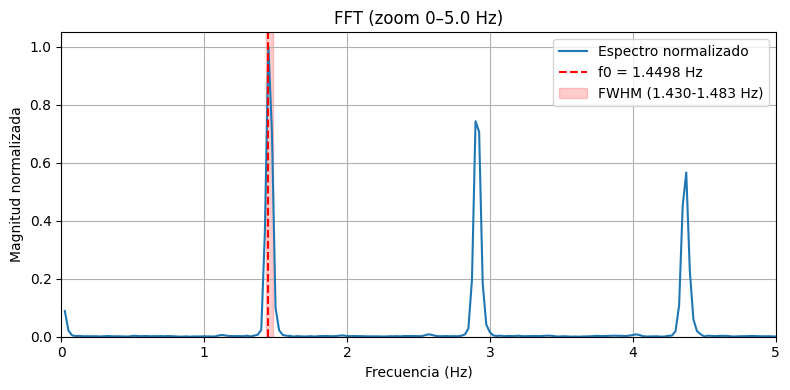

In [ ]:
# ==============================
# Sección 6b — Gráficas del espectro (normalizado y zoom)
# ==============================
# Zoom automático alrededor de f0
xlim_max = max(5.0, 3.0 * f0)
plt.figure(figsize=(8,4))
plt.plot(freqs_pos, Y_norm, label='Espectro normalizado')
plt.axvline(f0, color='r', linestyle='--', label=f'f0 = {f0:.4f} Hz')
plt.axvspan(f_left, f_right, color='r', alpha=0.2, label=f'FWHM ({f_left:.3f}-{f_right:.3f} Hz)')
plt.xlim(0, xlim_max)
plt.ylim(0, 1.05)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud normalizada")
plt.title(f"FFT (zoom 0–{xlim_max:.1f} Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Sección 7 — Envolvente y estimación del coeficiente de amortiguamiento γ
Se extrae la envolvente usando la transformada analítica de Hilbert; se aplica un suavizado robusto **solo** a la envolvente (filtro mediano).  
El ajuste se realiza sobre ln(envolvente_suavizada) vs t; la pendiente da `-γ`. Se informa `γ` y su error estándar (de `linregress`).


In [ ]:
# =============================================================
# SECCIÓN 7 - Envolvente y ajuste por Detección de Picos
# =============================================================
from scipy.signal import find_peaks, hilbert, medfilt

# 1) Envolvente analítica y suavizado
analytic = hilbert(voltajes_proc)
envelope = np.abs(analytic)

# Suavizar la envolvente antes de detectar picos (kernel impar)
K = DEFAULT_MEDFILT_KERNEL if 'DEFAULT_MEDFILT_KERNEL' in globals() else 101
if K % 2 == 0:
    K += 1
env_smooth = medfilt(envelope, kernel_size=K)

# 2) DETECCIÓN DE PICOS ROBUSTA
distancia_entre_picos = int((1.0 / f0) * fs_est * 0.85)
prom = 0.04 * np.max(env_smooth)  # ajustar según SNR
indices_picos, props = find_peaks(env_smooth, distance=distancia_entre_picos, prominence=prom, height=0)

if len(indices_picos) < 3:
    print("Error: No hay suficientes picos para ajustar.")
    gamma, gamma_err, r_value = np.nan, np.nan, 0
else:
    t_fit = t_sec[indices_picos]
    A_fit = env_smooth[indices_picos]
    lnA = np.log(A_fit)

    # Ajuste iterativo y eliminación de outliers (rejilla simple)
    mask = np.ones_like(lnA, dtype=bool)
    slope = intercept = r_value = std_err = np.nan
    for _ in range(4):
        slope, intercept, r_value, p_value, std_err = linregress(t_fit[mask], lnA[mask])
        pred = intercept + slope * t_fit
        resid = lnA - pred
        sigma = np.std(resid[mask])
        new_mask = np.abs(resid) < 2.5 * sigma
        if new_mask.sum() == mask.sum():
            break
        mask = new_mask

    gamma = -slope
    gamma_err = std_err
    print(f"gamma = {gamma:.6e} ± {gamma_err:.6e} (1/s); R2 = {r_value**2:.4f}")
    # conservar variables para graficar
    t_fit_used = t_fit[mask]
    A_fit_used = A_fit[mask]
    intercept_used = intercept
    slope_used = slope

gamma = 2.201058e-02 ± 1.805904e-04 (1/s); R2 = 0.9964


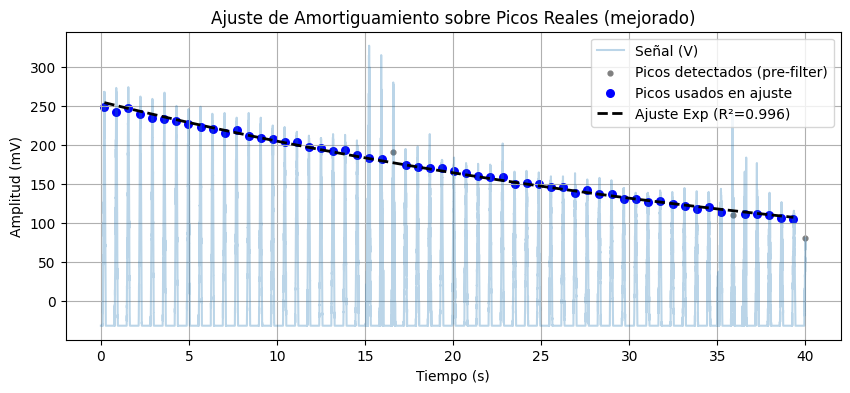

In [ ]:
# ==============================
# Sección 7b — Gráficas de envolvente y ajuste
# ==============================
plt.figure(figsize=(10,4))
plt.plot(t_sec, voltajes_proc, alpha=0.3, label='Señal (V)')
plt.scatter(t_fit, env_smooth[indices_picos], color='gray', s=12, label='Picos detectados (pre-filter)')
plt.scatter(t_fit_used, A_fit_used, color='blue', s=30, label='Picos usados en ajuste')
plt.plot(t_fit_used, np.exp(intercept_used + slope_used * t_fit_used), 'k--', lw=2, label=f'Ajuste Exp (R²={r_value**2:.3f})')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Ajuste de Amortiguamiento sobre Picos Reales (mejorado)")
plt.legend()
plt.grid(True)
plt.show()

## Sección 8 — Guardado de resultados procesados y metadatos
Se guardan: CSV con `t`, `voltaje crudo`, `voltaje interpolado`, `envolvente`, `envolvente_suavizada`; y un JSON de metadatos (fs_est, f0, σf, γ, σγ, timestamp).

In [ ]:
# ==============================
# Sección 8 — Guardado de resultados (ensayo único)
# ==============================
# Normalizar nombres: algunos bloques previos usan env_smooth / envelope_smooth
if 'env_smooth' in globals() and 'envelope_smooth' not in globals():
    envelope_smooth = env_smooth
if 'voltajes_interp' not in globals():
    voltajes_interp = voltajes  # fallback si no existe

# Preparar columnas adicionales: voltaje en V (si existe voltajes_v)
voltajes_v_col = voltajes_v if 'voltajes_v' in globals() else ( (voltajes - np.mean(voltajes)) * V_scale if 'V_scale' in globals() else np.nan * np.ones_like(voltajes) )

# Repetir scalars para guardar como columnas (misma longitud)
B_col = np.full_like(t_sec, B_est if 'B_est' in globals() else np.nan, dtype=float)
Berr_col = np.full_like(t_sec, delta_B if 'delta_B' in globals() else np.nan, dtype=float)
integral_col = np.full_like(t_sec, integral_emf if 'integral_emf' in globals() else np.nan, dtype=float)

proc_path = os.path.join(CARPETA_SALIDA, f"medicion_proc_{ts}.csv")
proc_data = np.column_stack((
    t_sec,
    voltajes,            # ADC raw counts (o lo que venga del ESP32)
    voltajes_interp,     # ADC interpolado (counts)
    voltajes_v_col,      # Voltios (si está disponible)
    envelope,            # envolvente (analítica)
    envelope_smooth,     # envolvente suavizada (medfilt)
    B_col,               # B estimado (repetido por fila)
    Berr_col,            # incertidumbre de B
    integral_col         # integral EMF (V·s)
))
header = "t_s,adc_raw,adc_interp,volt_V,envelope,envelope_smooth,B_T,B_err_T,integral_Vs"
np.savetxt(proc_path, proc_data, delimiter=",", header=header, comments="")
print(f"Datos procesados guardados en: {proc_path}")

# Metadatos más completos
meta = {
    "timestamp": ts,
    "raw_csv": raw_path if 'raw_path' in globals() else None,
    "proc_csv": proc_path,
    "fs_est_Hz": float(fs_est) if 'fs_est' in globals() else None,
    "f0_Hz": float(f0) if 'f0' in globals() else None,
    "sigma_f_Hz": float(sigma_f) if 'sigma_f' in globals() else None,
    "gamma_1_per_s": float(gamma) if 'gamma' in globals() else None,
    "gamma_err_1_per_s": float(gamma_err) if 'gamma_err' in globals() else None,
    "r2_gamma": float(r_value**2) if 'r_value' in globals() else None,
    # campos nuevos sobre B y calibración
    "B_T": float(B_est) if 'B_est' in globals() else None,
    "B_err_T": float(delta_B) if 'delta_B' in globals() else None,
    "integral_emf_Vs": float(integral_emf) if 'integral_emf' in globals() else None,
    "N_vueltas": int(N_VUELTAS) if 'N_VUELTAS' in globals() else None,
    "radio_bobina_m": float(RADIO_BOBINA) if 'RADIO_BOBINA' in globals() else None,
    "area_bobina_m2": float(AREA) if 'AREA' in globals() else None,
    "V_scale_V_per_count": float(V_scale) if 'V_scale' in globals() else None,
    "V_offset_V": float(V_offset) if 'V_offset' in globals() else None,
    "adc_negative_clipped": True  # indicaste que el ESP32 recorta negativos
}

meta_path = os.path.join(CARPETA_SALIDA, f"meta_{ts}.json")
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"Metadatos guardados en: {meta_path}")

Datos procesados guardados en: salida2\medicion_proc_20260204_151040.csv
Metadatos guardados en: salida2\meta_20260204_151040.json
